# Demo: Self-Attention + Causal Masking (From Scratch) with Learned Embeddings

This notebook demonstrates single-head scaled dot-product self-attention (Vaswani et al., 2017) **from scratch**:

You will:
- tokenize text at the word level
- learn token embeddings from scratch (`nn.Embedding`)
- learn Wq, Wk, Wv (and optional Wo)
- compute attention scores using explicit matrix multiplication
- apply softmax to get attention weights
- apply causal masking (decoder-style) to prevent attending to future tokens
- visualize attention weights with heatmaps



In [ ]:
import math
import re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [ ]:
torch.manual_seed(42)
np.random.seed(42)

## 1) Dataset

We start with a short sentence so the attention heatmap is easy to interpret.



In [ ]:
text = "attention helps models focus on important words"
tokens = re.findall(r"[A-Za-z]+", text.lower())

print("Tokens:", tokens)
print("Num tokens:", len(tokens))


Tokens: ['attention', 'helps', 'models', 'focus', 'on', 'important', 'words']
Num tokens: 7


## 2) Vocabulary + Next-token Prediction Data

We train an autoregressive objective:
- input:  t0 t1 ... t(n-2)
- target: t1 t2 ... t(n-1)

This provides a learning signal so embeddings and Q/K/V projections become meaningful.


In [ ]:
vocab = sorted(set(tokens))
stoi = {w:i for i, w in enumerate(vocab)}
itos = {i:w for w, i in stoi.items()}

ids = torch.tensor([stoi[w] for w in tokens], dtype=torch.long)

# Next-token prediction
x = ids[:-1].unsqueeze(0).to(device)   # [1, T] input sequence
y = ids[1:].unsqueeze(0).to(device)    # [1, T] gtarget sequence

print("Vocab:", vocab)
print("x tokens:", [itos[i.item()] for i in x[0]])
print("y tokens:", [itos[i.item()] for i in y[0]])


Vocab: ['attention', 'focus', 'helps', 'important', 'models', 'on', 'words']
x tokens: ['attention', 'helps', 'models', 'focus', 'on', 'important']
y tokens: ['helps', 'models', 'focus', 'on', 'important', 'words']


## 3) Self-attention implementation (from scratch)

We implement:
- scaled dot-product attention: softmax((QKᵀ)/sqrt(d_k)) V
- causal mask (lower triangular)
- heatmap plotting


In [ ]:
def make_causal_mask(T: int, device: str):
    """
    Boolean mask [T, T] where True means 'allowed'.
    Lower-triangular => position i can attend to positions <= i.
    """
    return torch.tril(torch.ones((T, T), device=device)).bool()

In [ ]:
make_causal_mask(T=5, device=device)

tensor([[ True, False, False, False, False],
        [ True,  True, False, False, False],
        [ True,  True,  True, False, False],
        [ True,  True,  True,  True, False],
        [ True,  True,  True,  True,  True]], device='cuda:0')

Query (Q) → “What am I looking for?”

Key (K) → “What do I contain?”

Value (V) → “What information should I pass along?”

Q, K, V are shaped: [B, T, d_k]

B = batch size

T = number of tokens

d_k = size of Q/K vectors (projection dimension)

So each token has: a query vector, a key vector, a value vector

In [ ]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q, K, V: [B, T, d_k]
    mask: [T, T] boolean, True=allowed, False=blocked
    """
    d_k = Q.size(-1)

    #compute how much each token i should pay attention to token j
    scores = (Q @ K.transpose(-2, -1)) / math.sqrt(d_k)  # [B, T, T]

    if mask is not None:
        scores = scores.masked_fill(~mask, -1e9)

    #converting attention into probabilities
    attn = F.softmax(scores, dim=-1)    # [B, T, T]

    #weighted sum of all values
    out = attn @ V                      # [B, T, d_k]
    return out, attn


In [ ]:
def plot_attention(attn, tokens, title):
    if isinstance(attn, torch.Tensor):
        attn = attn.detach().cpu().numpy()

    plt.figure(figsize=(8, 6))
    plt.imshow(attn, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(tokens)), tokens, rotation=45, ha="right")
    plt.yticks(range(len(tokens)), tokens)
    plt.title(title)
    plt.ylabel("Input Token")
    plt.xlabel("Token of Focus")
    plt.tight_layout()
    plt.show()

## 4) Tiny single-head attention Language Model (learn embeddings + train Q/K/V)

We learn:
- token embeddings
- Wq, Wk, Wv, Wo
- a vocab classifier head (lm_head)

We train with causal masking so it behaves like a decoder attention block.


In [ ]:
class SingleHeadSelfAttentionLM(nn.Module):
    def __init__(self, vocab_size, d_model=64, d_k=64):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.d_k = d_k

        # Trainable learned embeddings
        self.embed = nn.Embedding(vocab_size, d_model)

        # Trainable projections
        self.Wq = nn.Linear(d_model, d_k, bias=False)
        self.Wk = nn.Linear(d_model, d_k, bias=False)
        self.Wv = nn.Linear(d_model, d_k, bias=False)

        # Optional projection after attention
        self.Wo = nn.Linear(d_k, d_k, bias=False)

        # Output head to vocab
        self.lm_head = nn.Linear(d_k, vocab_size, bias=False)

    def forward(self, x_ids, use_causal_mask=True):
        """
        x_ids: [B, T]
        returns:
          logits: [B, T, vocab_size]
          attn: [B, T, T]
        """

        #B= Batch size, T= no. tokens
        B, T = x_ids.shape

        h = self.embed(x_ids)  # [B, T, d_model]

        Q = self.Wq(h)         # [B, T, d_k]
        K = self.Wk(h)
        V = self.Wv(h)

        mask = make_causal_mask(T, x_ids.device) if use_causal_mask else None
        out, attn = scaled_dot_product_attention(Q, K, V, mask=mask)  # [B, T, d_k]

        out = self.Wo(out)       # [B, T, d_k]

        #next token prediction
        logits = self.lm_head(out)  # [B, T, vocab_size]
        return logits, attn


## 5) Train with next-token prediction

We train on a tiny dataset, so this is just to make attention **not random**.
Even a few hundred steps is enough to produce structured attention.


In [ ]:
model = SingleHeadSelfAttentionLM(vocab_size=len(vocab), d_model=64, d_k=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

epochs = 400
losses = []

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    logits, _ = model(x, use_causal_mask=True)  # [1, T, V]
    loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))

    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f}")


Epoch   50 | Loss: 0.2784
Epoch  100 | Loss: 0.2313
Epoch  150 | Loss: 0.2311
Epoch  200 | Loss: 0.2311
Epoch  250 | Loss: 0.2311
Epoch  300 | Loss: 0.2311
Epoch  350 | Loss: 0.2311
Epoch  400 | Loss: 0.2311


## 6) Visualize attention: Unmasked vs Causal Masked

We run attention on the full sentence and plot both heatmaps:
1) Unmasked attention
2) Causal masked attention (decoder-style)


In [ ]:
model.eval()
with torch.no_grad():
    full_ids = ids.unsqueeze(0).to(device)  # [1, Tfull]
    _, attn_unmasked = model(full_ids, use_causal_mask=False)
    _, attn_masked   = model(full_ids, use_causal_mask=True)

full_tokens = [itos[i.item()] for i in full_ids[0]]

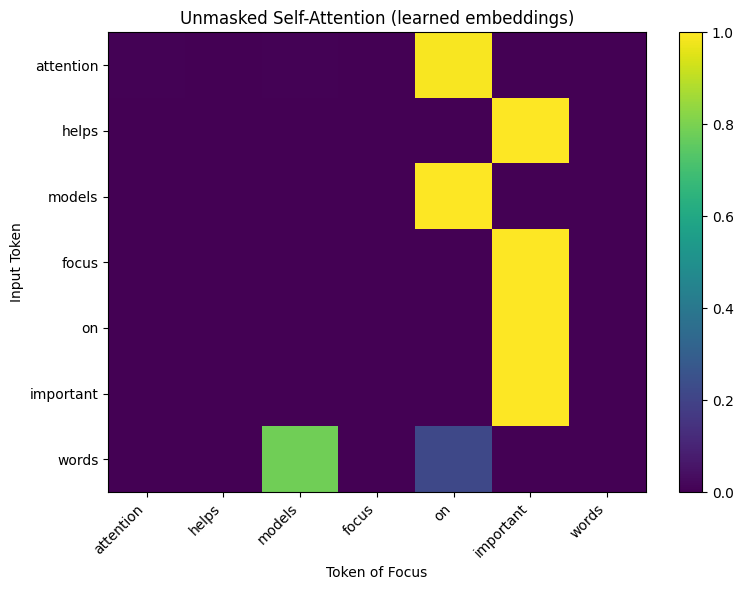

In [ ]:
plot_attention(attn_unmasked[0], full_tokens, "Unmasked Self-Attention (learned embeddings)")

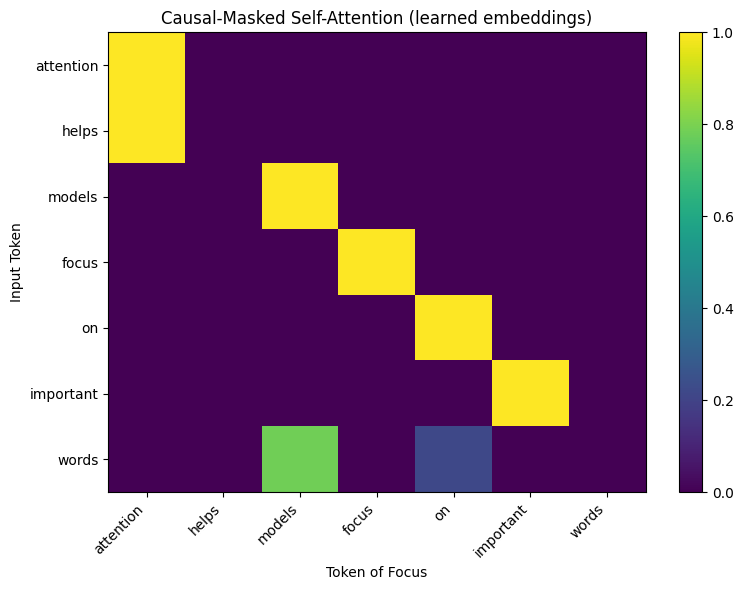

In [ ]:
plot_attention(attn_masked[0], full_tokens, "Causal-Masked Self-Attention (learned embeddings)")

## 8) Sanity check: masked attention should not attend to the future

We sum attention weights above the diagonal.
It should be ~0 if the mask is correct.


In [ ]:
with torch.no_grad():
    A = attn_masked[0].detach().cpu()
    upper = torch.triu(torch.ones_like(A), diagonal=1).bool()
    leaked_mass = A[upper].sum().item()

print("Total attention mass above diagonal (should be ~0):", leaked_mass)


Total attention mass above diagonal (should be ~0): 0.0
